In [2]:
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd
import numpy as np

pb_atac_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes_times/agg_atac_ct_time.h5ad")
pb_rna_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes_times/agg_rna_ct_time.h5ad")    
gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_10kb.csv")
gene_peaks_20kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_20kb.csv")
gene_peaks_50kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_50kb.csv")
gene_peaks_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_100kb.csv")

In [3]:
#taking the minimum non-zero value in the pb_rna_ct_time matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np
non_zero_mask = (pb_rna_ct_time.X > 0)
epsilon_rna = np.min(pb_rna_ct_time.X[non_zero_mask])

#taking the minimum non-zero value in the pb_atac_ct_time matrix to add it to all values before log transformation to avoid taking log of zero
non_zero_mask = (pb_atac_ct_time.X > 0)
epsilon_at= np.min(pb_atac_ct_time.X[non_zero_mask])

In [4]:
#log transformation (for norm. distribution) & scaling 10000000+1
#log scaling both datasets by multiplying by 10 million and adding 1 to avoid log(0) issues, then taking log10
pb_rna_ct_time.X = np.log10((pb_rna_ct_time.X+ epsilon_rna)*10000000)
pb_atac_ct_time.X = np.log10((pb_atac_ct_time.X+ epsilon_at)*10000000)
print(pb_atac_ct_time.X)
print(pb_rna_ct_time.X)

[[ 0.58441806  0.3880675   1.06160453 ...  0.77350882  4.31687307
   4.26583112]
 [ 0.55057849  0.77497146  1.06311131 ...  0.71223775  4.46490082
   4.42605741]
 [ 0.5812014   0.31814683  1.47411151 ...  0.5812014   4.29971273
   4.26136205]
 ...
 [ 0.68050573  1.00535566  1.21338458 ...  0.87262121  4.28769769
   4.24816241]
 [ 0.56626071  0.77136092  1.20173285 ...  0.96576803  4.32052555
   4.22963983]
 [-0.4579541  -0.4579541   0.93853073 ... -0.4579541   4.43176072
   4.34928772]]
[[1.25848578 0.87479245 1.20428309 ... 4.57135069 0.72978795 0.04624963]
 [1.29820203 0.76356469 1.02082851 ... 4.59115367 1.18129282 0.76356469]
 [0.9837023  1.0959172  1.50987238 ... 4.60309939 0.9837023  1.18501005]
 ...
 [0.04624963 0.04624963 0.94900871 ... 4.66963744 0.04624963 0.04624963]
 [1.15741357 0.04624963 1.44129868 ... 4.6874499  0.04624963 1.44129868]
 [0.04624963 1.46040775 1.63088453 ... 4.6812724  0.04624963 0.04624963]]


In [5]:
gene_peaks_100kb[0:10]

,gene_id,assigned_peaks
0,rpl24,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
1,cep97,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
2,nfkbiz,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
3,eed,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
4,hikeshi,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
5,tmem39a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
6,ildr1a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
7,gpa33a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
8,f7l,"['1-11007-12962', '1-13276-13705', '1-14059-14..."
9,f7,"['1-21199-21555', '1-21590-23611', '1-27097-29..."


In [6]:
# OLS regression of gene expression on peak accessibility per gene
# Two-stage approach:
# 1) fit_regularized on all assigned peaks to rank/select features
# 2) refit standard OLS on the selected subset only
import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.multitest import multipletests

window_labels = ["10kb", "20kb", "50kb", "100kb"]

# ── per-window OLS result stores ──────────────────────────────────────────────
gene_peak_10kb_ols_results  = {}
gene_peak_20kb_ols_results  = {}
gene_peak_50kb_ols_results  = {}
gene_peak_100kb_ols_results = {}

ols_result_stores = {
    "10kb":  gene_peak_10kb_ols_results,
    "20kb":  gene_peak_20kb_ols_results,
    "50kb":  gene_peak_50kb_ols_results,
    "100kb": gene_peak_100kb_ols_results,
}

window_assignments_raw = {
    "10kb":  gene_peaks_10kb,
    "20kb":  gene_peaks_20kb,
    "50kb":  gene_peaks_50kb,
    "100kb": gene_peaks_100kb,
}

# ── 1. OLS loop per window → per gene ────────────────────────────────────────
for window_label, gene_peaks_df in window_assignments_raw.items():
    ols_results = ols_result_stores[window_label]

    for gene_id in gene_peaks_df["gene_id"]:
        # ── retrieve & parse assigned peaks ───────────────────────────────────
        assigned_peaks_raw = gene_peaks_df.loc[
            gene_peaks_df["gene_id"] == gene_id, "assigned_peaks"
        ].iloc[0]

        if isinstance(assigned_peaks_raw, str):
            assigned_peaks = ast.literal_eval(assigned_peaks_raw)
        else:
            assigned_peaks = assigned_peaks_raw

        # keep only peaks present in ATAC object
        assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

        peak_ols = {}
        if len(assigned_peaks) == 0:
            ols_results[gene_id] = peak_ols
            continue

        # ── response variable: gene expression (y) ────────────────────────────
        y = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel().astype(float)

        # skip gene if expression is constant or sample size is too small
        if np.std(y) == 0 or y.shape[0] < 2:
            ols_results[gene_id] = peak_ols
            continue

        # ── predictor matrix: accessibility for all assigned peaks ────────────
        X_raw = np.asarray(pb_atac_ct_time[:, assigned_peaks].X).astype(float)
        n_samples = X_raw.shape[0]
        n_peaks_total = X_raw.shape[1]

        # select at most n_samples - 2 peaks, to fit a model with intercept and avoid perfect fit issues
        n_select = max(1, min(n_peaks_total, n_samples - 2))

        # stage 1: regularized fit for feature ranking, with fallback to correlation ranking if it fails
        X_full = add_constant(X_raw, prepend=True)
        try:
            reg_result = OLS(y, X_full).fit_regularized(alpha=0.5, L1_wt=0.5)
            reg_params = np.asarray(reg_result.params)
        except Exception:
            # fallback: rank by simple correlation with y if regularized fit fails
            reg_params = np.zeros(n_peaks_total + 1, dtype=float)
            for idx in range(n_peaks_total):
                x_col = X_raw[:, idx]
                if np.std(x_col) == 0:
                    reg_params[idx + 1] = 0.0
                else:
                    corr = np.corrcoef(x_col, y)[0, 1]
                    reg_params[idx + 1] = 0.0 if np.isnan(corr) else corr

        # rank by the regularized coefficients themselves (excluding intercept)
        peak_scores = np.abs(reg_params[1:])
        ranked_peak_indices = np.argsort(peak_scores)[::-1]
        selected_peak_indices = ranked_peak_indices[:n_select]
        selected_peak_indices = np.sort(selected_peak_indices)
        selected_peaks = [assigned_peaks[idx] for idx in selected_peak_indices]

        # stage 2: refit standard OLS on the selected peaks only
        X_selected = X_raw[:, selected_peak_indices]
        X = add_constant(X_selected, prepend=True)
        model = OLS(y, X)
        result = model.fit()
        conf_int = result.conf_int()

        peak_ols["selection"] = {
            "n_samples": n_samples,
            "n_peaks_total": n_peaks_total,
            "n_selected": len(selected_peaks),
            "selected_peaks": selected_peaks,
            "regularized_params": reg_params.tolist(),
        }

        peak_ols["model"] = {
            "intercept": result.params[0],
            "r_squared": result.rsquared,
            "adj_r_squared": result.rsquared_adj,
            "f_statistic": result.fvalue,
            "f_pval": result.f_pvalue,
            "aic": result.aic,
            "bic": result.bic,
            "padj": np.nan,
        }

        for peak_idx, peak_id in enumerate(selected_peaks):
            param_idx = peak_idx + 1  # +1 because index 0 is intercept
            peak_ols[peak_id] = {
                "coef": result.params[param_idx],
                "std_err": result.bse[param_idx],
                "t_stat": result.tvalues[param_idx],
                "pval": result.pvalues[param_idx],
                "conf_int_lower": conf_int[param_idx, 0],
                "conf_int_upper": conf_int[param_idx, 1],
                "padj": np.nan,
            }

        ols_results[gene_id] = peak_ols

    print(f"[{window_label}] Two-stage OLS complete — {len(ols_results)} genes processed")



# ── 3. Build tidy summary DataFrame ──────────────────────────────────────────
all_ols_results = []

for window_label, ols_results in ols_result_stores.items():
    for gene_id, peak_ols in ols_results.items():
        for peak_id, stats in peak_ols.items():
            if peak_id in {"model", "selection"}:
                continue
            if not isinstance(stats, dict):
                continue

            pval = stats.get("pval", np.nan)
            padj = stats.get("padj", np.nan)

            if np.isfinite(pval) and 0 < pval <= 1:
                all_ols_results.append({
                    "window": window_label,
                    "gene": gene_id,
                    "peak": peak_id,
                    "coef": stats.get("coef", np.nan),
                    "std_err": stats.get("std_err", np.nan),
                    "t_stat": stats.get("t_stat", np.nan),
                    "conf_int_lower": stats.get("conf_int_lower", np.nan),
                    "conf_int_upper": stats.get("conf_int_upper", np.nan),
                    "pval": pval,
                    "neglog10_pval": -np.log10(pval),
                    "padj": padj,
                    "neglog10_padj": -np.log10(padj) if np.isfinite(padj) and padj > 0 else np.nan,
                })

ols_res_df = pd.DataFrame(all_ols_results)

ols_res_df["window"] = pd.Categorical(
    ols_res_df["window"],
    categories=window_labels,
    ordered=True,
)

print(f"\nOLS summary DataFrame: {ols_res_df.shape[0]:,} peak–gene pairs")
print(ols_res_df.head())



[10kb] Two-stage OLS complete — 19380 genes processed
[20kb] Two-stage OLS complete — 19380 genes processed
[50kb] Two-stage OLS complete — 19380 genes processed
[100kb] Two-stage OLS complete — 19380 genes processed

OLS summary DataFrame: 3,308,528 peak–gene pairs
  window   gene           peak      coef   std_err    t_stat  conf_int_lower  \
0   10kb  rpl24    1-2372-3057  0.032466  0.036480  0.889952       -0.039513   
1   10kb  rpl24    1-3427-4032 -0.026348  0.044143 -0.596882       -0.113445   
2   10kb  rpl24    1-4469-7268  0.199903  0.110873  1.802994       -0.018858   
3   10kb  rpl24    1-9541-9969 -0.082729  0.045903 -1.802238       -0.173300   
4   10kb  rpl24  1-11007-12962  0.176715  0.172822  1.022526       -0.164277   

   conf_int_upper      pval  neglog10_pval  padj  neglog10_padj  
0        0.104445  0.374666       0.426355   NaN            NaN  
1        0.060749  0.551328       0.258590   NaN            NaN  
2        0.418664  0.073043       1.136420   NaN      

In [9]:
#save results
ols_res_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_ols_ct_time_results.csv.gz", index=False)

#read results
ols_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_ols_ct_time_results.csv.gz")    

/tmp/ipykernel_1193339/3636771642.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='window', ylabel='neglog10_pval'>

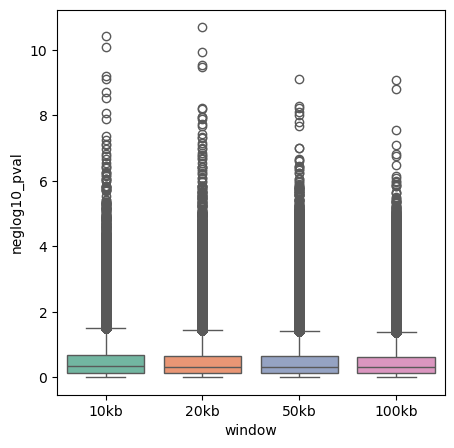

In [10]:
#plot the distribution of the pvalues for all windows
import matplotlib.pyplot as plt
import seaborn as sns   
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(
    data=ols_res_df.dropna(subset=["pval"]),
    x="window",
    y="neglog10_pval",
    palette="Set2",
    ax=ax,
)

In [11]:
#count the na
ols_res_df["pval_na"] = ols_res_df["pval"].isna()
pval_na_counts = ols_res_df.groupby("window").size().reset_index(name="pval_na_count")
print("\nCount of peaks per window:")
print(pval_na_counts)   


Count of peaks per window:
  window  pval_na_count
0  100kb        1853529
1   10kb         172007
2   20kb         360340
3   50kb         922652
